# Agricultural Climate Risk Analysis in Peru
## A Geospatial Raster Data Science Lab

**Mission:** You are a data analyst at Peru's Ministry of Agriculture. Your team needs to identify which districts face the greatest climate risk for crop production — specifically:
- **Drought risk**: Districts with high maximum temperatures AND low rainfall
- **Frost risk**: Districts with dangerously low minimum temperatures in growing seasons
- **Water access context**: Districts located near river networks

By the end of this lab you will be able to:
1. Read and inspect raster data (bands, metadata, coordinate systems)
2. Visualize multi-band raster datasets with proper geographic extent
3. Crop/clip rasters to vector boundaries — three different methods
4. Compute zonal statistics to link raster pixels to administrative units
5. Combine multiple rasters into a composite agricultural risk index

**Available Data:**

| File | Description | Format |
|------|-------------|--------|
| `Prec_raster.tif` | Precipitation — 5 time periods | Raster (133×198 px, 5 bands) |
| `tmax_raster.tif` | Maximum temperature — 5 time periods | Raster (285×397 px, 5 bands) |
| `tmin_raster.tif` | Minimum temperature — 5 time periods | Raster (285×397 px, 5 bands) |
| `shape_file/DISTRITOS.shp` | Peru district boundaries | Vector (1,873 districts) |
| `Rios_quebradas_ANA_geogpsperu_SuyoPomalia.shp` | River network | Vector (LineStrings) |

In [3]:
# Uncomment to install required packages
!pip install rasterio rasterstats geopandas matplotlib numpy pandas seaborn

  Using cached fiona-1.10.1.tar.gz (444 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [1 lines of output]
      CRITICAL:root:A GDAL API version must be specified. Provide a path to gdal-config using a GDAL_CONFIG environment variable or use a GDAL_VERSION environment variable.
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'fiona' when getting requirements to build wheel


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.plot import plotting_extent
from rasterio.transform import array_bounds
from rasterstats import zonal_stats
from shapely.geometry import box

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All libraries loaded successfully.')
print(f'  rasterio  version: {rasterio.__version__}')
print(f'  geopandas version: {gpd.__version__}')

All libraries loaded successfully.
  rasterio  version: 1.5.0
  geopandas version: 1.1.3


## Section 1: Understanding Raster Data

### What is a raster?

A **raster** is a grid of cells (pixels) where each cell holds a numeric value for a geographic location. Think of it as a spreadsheet overlaid on a map:

```
Longitude: -81.25  -81.15  -81.05  -80.95  ...
Latitude:
 0.95      [  8.2] [  9.1] [ 12.3] [ 11.0] ...
 0.85      [  7.8] [ 10.2] [ 14.1] [ 13.5] ...
```

### Key raster concepts

| Concept | Description |
|---------|-------------|
| **Band** | A single layer of values. Multi-band rasters hold several layers (e.g., one per time period). |
| **Resolution** | Area each pixel covers. Our precipitation raster uses ~0.10° per pixel (~11 km at the equator). |
| **CRS** | Coordinate Reference System. All our files use **EPSG:4326** (WGS 84 — the GPS standard). |
| **NoData** | A sentinel value (NaN, -9999) meaning "no measurement here" — common over ocean areas. |
| **Affine Transform** | The formula that converts pixel (row, col) → real-world (latitude, longitude). |

### Why rasters for climate data?
Weather station measurements (point data) are interpolated onto a regular grid. This compact format is fast to compute over and integrates naturally with satellite imagery.

In [5]:
# ── Read precipitation raster metadata ──
prec_path = 'Prec_raster.tif'

with rasterio.open(prec_path) as src:
    print('=== Precipitation Raster Metadata ===')
    print(f'  Width  (columns) : {src.width} pixels')
    print(f'  Height (rows)    : {src.height} pixels')
    print(f'  Bands            : {src.count}  (5 time periods)')
    print(f'  CRS              : {src.crs}')
    print(f'  NoData value     : {src.nodata}')
    print(f'  Data type        : {src.dtypes[0]}')
    print()
    print(f'  Affine Transform : {src.transform}')
    print()
    print('  Bounding box:')
    print(f'    West  (left)  : {src.bounds.left:.4f} deg')
    print(f'    East  (right) : {src.bounds.right:.4f} deg')
    print(f'    South (bottom): {src.bounds.bottom:.4f} deg')
    print(f'    North (top)   : {src.bounds.top:.4f} deg')
    print()
    px_km = src.transform.a * 111
    print(f'  Pixel size: {src.transform.a:.4f} deg (~{px_km:.1f} km at equator)')

    # Store for later use
    prec_bands    = src.read()        # shape: (bands, rows, cols) = (5, 198, 133)
    prec_meta     = src.meta.copy()
    prec_transform = src.transform
    prec_crs      = src.crs
    prec_extent   = plotting_extent(src)

print()
print(f'Array shape loaded: {prec_bands.shape}  -> (bands, rows, cols)')

=== Precipitation Raster Metadata ===
  Width  (columns) : 133 pixels
  Height (rows)    : 198 pixels
  Bands            : 5  (5 time periods)
  CRS              : EPSG:4326
  NoData value     : None
  Data type        : float32

  Affine Transform : | 0.10, 0.00,-81.25|
| 0.00,-0.10, 0.95|
| 0.00, 0.00, 1.00|

  Bounding box:
    West  (left)  : -81.2500 deg
    East  (right) : -67.9502 deg
    South (bottom): -18.8500 deg
    North (top)   : 0.9500 deg

  Pixel size: 0.1000 deg (~11.1 km at equator)

Array shape loaded: (5, 198, 133)  -> (bands, rows, cols)


In [6]:
# ── Read temperature rasters ──
tmax_path = 'tmax_raster.tif'
tmin_path = 'tmin_raster.tif'

with rasterio.open(tmax_path) as src:
    print('=== Max Temperature Raster ===')
    print(f'  Size: {src.width}w x {src.height}h px | {src.count} bands | {src.crs}')
    print(f'  Pixel size: {src.transform.a:.4f} deg (~{src.transform.a * 111:.1f} km)')
    tmax_bands     = src.read()
    tmax_meta      = src.meta.copy()
    tmax_transform = src.transform
    tmax_extent    = plotting_extent(src)

with rasterio.open(tmin_path) as src:
    print()
    print('=== Min Temperature Raster ===')
    print(f'  Size: {src.width}w x {src.height}h px | {src.count} bands | {src.crs}')
    print(f'  Pixel size: {src.transform.a:.4f} deg (~{src.transform.a * 111:.1f} km)')
    tmin_bands     = src.read()
    tmin_meta      = src.meta.copy()
    tmin_transform = src.transform
    tmin_extent    = plotting_extent(src)

print()
print('Key observation: Temperature rasters (0.05 deg/px) have HIGHER resolution than')
print('precipitation (0.10 deg/px). Different data products have different native resolutions.')
print('All three rasters share CRS EPSG:4326 and can be overlaid directly.')

=== Max Temperature Raster ===
  Size: 285w x 397h px | 5 bands | EPSG:4326
  Pixel size: 0.0500 deg (~5.5 km)

=== Min Temperature Raster ===
  Size: 285w x 397h px | 5 bands | EPSG:4326
  Pixel size: 0.0500 deg (~5.5 km)

Key observation: Temperature rasters (0.05 deg/px) have HIGHER resolution than
precipitation (0.10 deg/px). Different data products have different native resolutions.
All three rasters share CRS EPSG:4326 and can be overlaid directly.


In [7]:
# ── Load vector shapefiles ──
districts_path = os.path.join('shape_file', 'DISTRITOS.shp')
rivers_path    = 'Rios_quebradas_ANA_geogpsperu_SuyoPomalia.shp'

gdf_districts = gpd.read_file(districts_path)
gdf_rivers    = gpd.read_file(rivers_path)

print('=== District Boundaries ===')
print(f'  Features (districts)    : {len(gdf_districts):,}')
print(f'  CRS                     : {gdf_districts.crs}')
print(f'  Columns                 : {gdf_districts.columns.tolist()}')

print()
print('=== River Network ===')
print(f'  Features (river segments): {len(gdf_rivers):,}')
print(f'  CRS                      : {gdf_rivers.crs}')
print(f'  Geometry types           : {gdf_rivers.geom_type.unique().tolist()}')

print()
print('--- Sample district records ---')
display(gdf_districts[['IDDPTO', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO']].head(5))

=== District Boundaries ===
  Features (districts)    : 1,873
  CRS                     : EPSG:4326
  Columns                 : ['IDDPTO', 'DEPARTAMEN', 'IDPROV', 'PROVINCIA', 'IDDIST', 'DISTRITO', 'CAPITAL', 'CODCCPP', 'AREA', 'FUENTE', 'geometry']

=== River Network ===
  Features (river segments): 1,225
  CRS                      : EPSG:4326
  Geometry types           : ['LineString']

--- Sample district records ---


,IDDPTO,DEPARTAMEN,PROVINCIA,DISTRITO
0,10,HUANUCO,PUERTO INCA,CODO DEL POZUZO
1,10,HUANUCO,PUERTO INCA,TOURNAVISTA
2,25,UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT
3,25,UCAYALI,PADRE ABAD,IRAZOLA
4,25,UCAYALI,PADRE ABAD,NESHUYA


### Understanding the Affine Transform

The affine transform encodes how pixel indices map to geographic coordinates:

```
longitude = left_edge + col × pixel_width
latitude  = top_edge  + row × pixel_height   (negative: rows increase downward)
```

For our precipitation raster (transform `| 0.10, 0.00, -81.25 | 0.00, -0.10, 0.95 |`):

| Parameter | Value | Meaning |
|-----------|-------|---------|
| Left edge | -81.25° | Western boundary (Peru's Pacific coast) |
| Top edge  |  0.95°  | Northern boundary (near Ecuador border) |
| Pixel width  | +0.10° | Each column moves 0.10° eastward |
| Pixel height | -0.10° | Each row moves 0.10° southward |

So pixel **(row=0, col=0)** — top-left corner — is at **longitude -81.25°, latitude 0.95°**.

Without the transform, the raster is just a grid of anonymous numbers with no geographic meaning.

## Section 2: Visualizing Raster Data

`matplotlib.pyplot.imshow()` renders the 2D pixel array as a color image.

**Key parameters for geographic raster plots:**

| Parameter | Purpose | Recommended value |
|-----------|---------|-------------------|
| `cmap` | Color mapping | `'Blues'` for precip, `'Reds'` for max temp, `'coolwarm'` for min temp |
| `extent` | Show real coordinates on axes | `(left, right, bottom, top)` from `plotting_extent()` |
| `origin='upper'` | Row 0 at the top (geographic convention) | Always use this |
| `vmin` / `vmax` | Fix the color scale | Use the same range across all bands for fair comparison |

**NoData masking:** Replace fill values with `np.nan` before plotting so ocean/border pixels render as transparent (white), not as extreme colors that distort the scale.

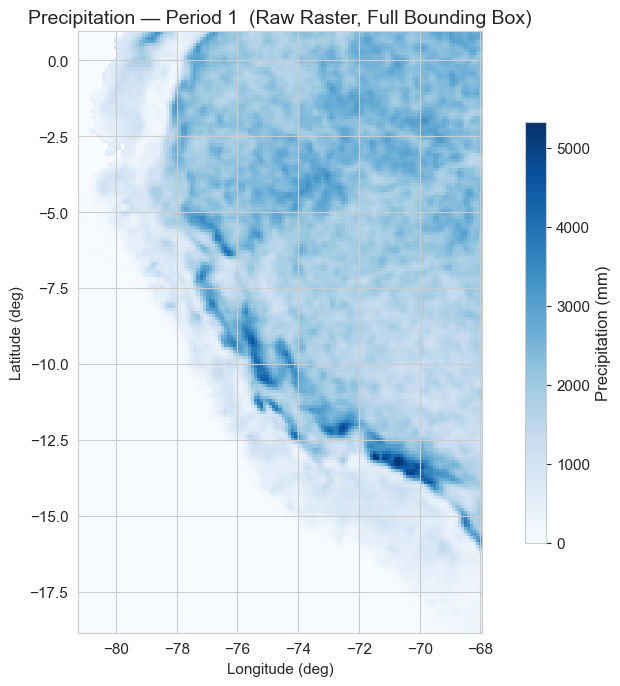

Observation: The raster covers a rectangle larger than Peru.
Pixels outside Peru (ocean, neighbors) appear blank.
Section 3 will crop this to Peru's actual boundary.


In [8]:
# ── Single band with geographic extent ──
prec_b1 = prec_bands[0].astype(float)
prec_b1[prec_b1 < 0] = np.nan        # negative precipitation is fill/NoData

fig, ax = plt.subplots(figsize=(9, 7))
img = ax.imshow(prec_b1, cmap='Blues', extent=prec_extent, origin='upper')
cbar = plt.colorbar(img, ax=ax, shrink=0.7)
cbar.set_label('Precipitation (mm)', fontsize=12)
ax.set_title('Precipitation — Period 1  (Raw Raster, Full Bounding Box)', fontsize=14)
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
plt.tight_layout()
plt.show()

print('Observation: The raster covers a rectangle larger than Peru.')
print('Pixels outside Peru (ocean, neighbors) appear blank.')
print('Section 3 will crop this to Peru\'s actual boundary.')

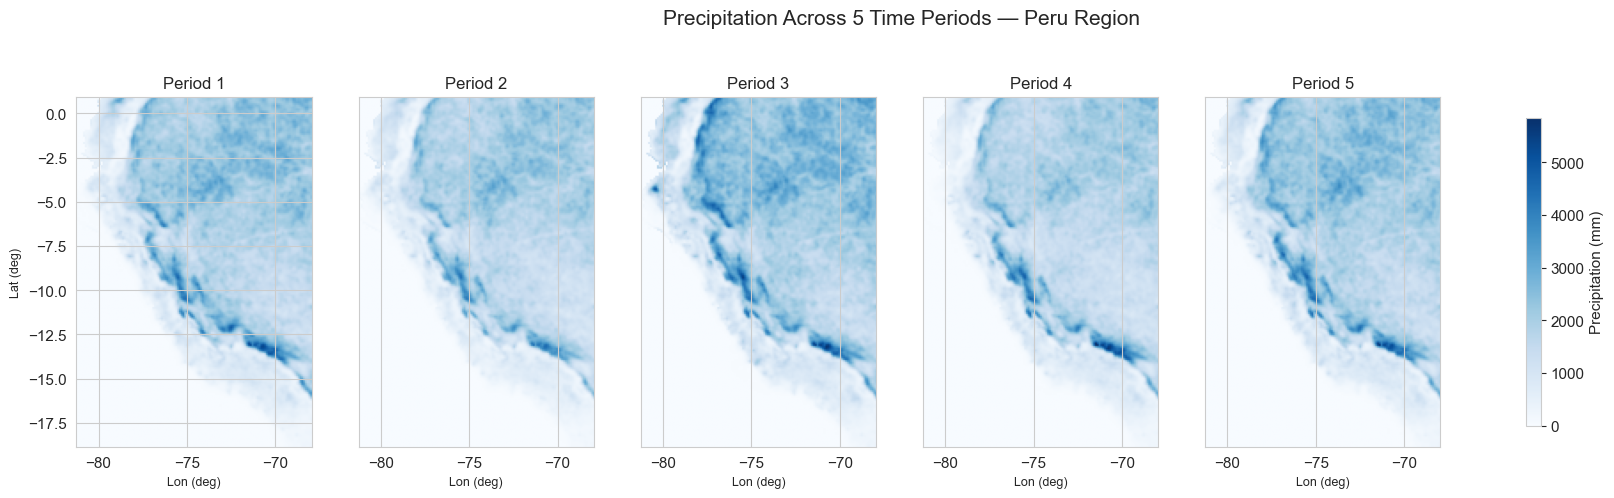

Shared vmin/vmax ensures colors are directly comparable across periods.


In [9]:
# ── All 5 precipitation bands side-by-side ──
# Share vmin/vmax so all panels use the SAME color scale — essential for comparison
all_prec = prec_bands.astype(float)
all_prec[all_prec < 0] = np.nan
vmin_p, vmax_p = np.nanmin(all_prec), np.nanmax(all_prec)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Precipitation Across 5 Time Periods — Peru Region', fontsize=15, y=1.02)

for i, ax in enumerate(axes):
    im = ax.imshow(all_prec[i], cmap='Blues', extent=prec_extent, origin='upper',
                   vmin=vmin_p, vmax=vmax_p)
    ax.set_title(f'Period {i + 1}', fontsize=12)
    ax.set_xlabel('Lon (deg)', fontsize=9)
    if i == 0:
        ax.set_ylabel('Lat (deg)', fontsize=9)
    else:
        ax.set_yticks([])

fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.8, label='Precipitation (mm)')
plt.show()

print('Shared vmin/vmax ensures colors are directly comparable across periods.')

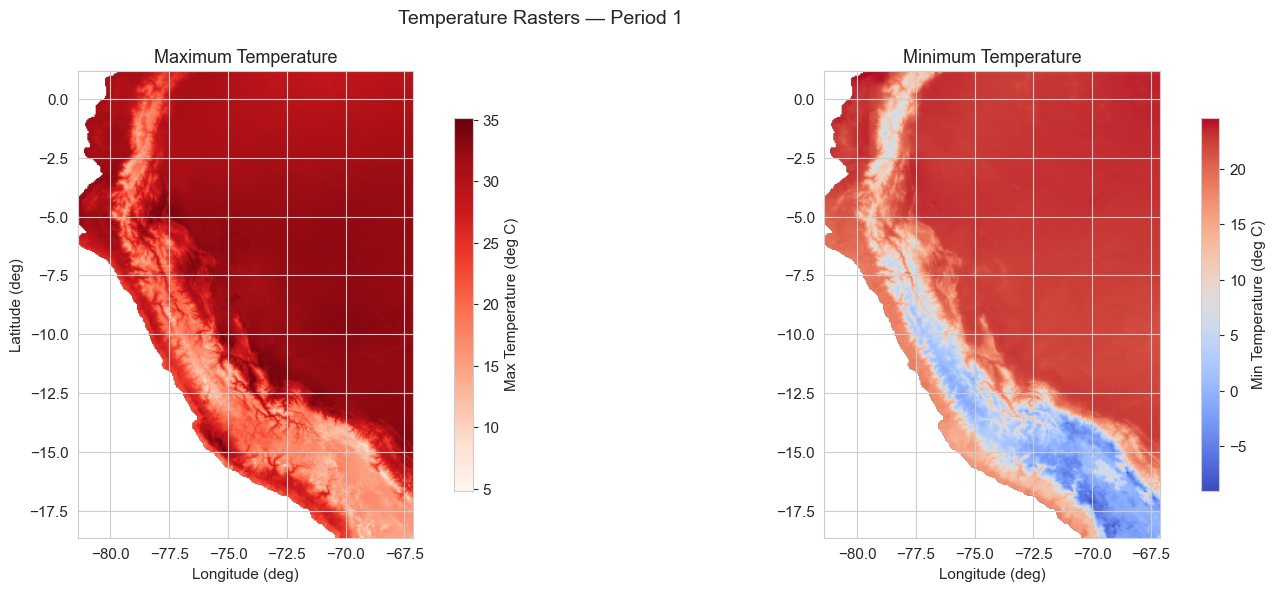

Tmax Band 1  range: 4.8 C  to  35.2 C
Tmin Band 1  range: -9.1 C  to  24.6 C

coolwarm colormap naturally shows cold Andean highlands (blue)
and warm coastal/Amazon lowlands (red).


In [10]:
# ── Max and Min temperature side-by-side ──
tmax_b1 = tmax_bands[0].astype(float)
tmax_b1[tmax_b1 < -100] = np.nan     # typical NoData threshold for temperature

tmin_b1 = tmin_bands[0].astype(float)
tmin_b1[tmin_b1 < -100] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Temperature Rasters — Period 1', fontsize=14)

im1 = axes[0].imshow(tmax_b1, cmap='Reds', extent=tmax_extent, origin='upper')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='Max Temperature (deg C)')
axes[0].set_title('Maximum Temperature', fontsize=13)
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')

im2 = axes[1].imshow(tmin_b1, cmap='coolwarm', extent=tmin_extent, origin='upper')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Min Temperature (deg C)')
axes[1].set_title('Minimum Temperature', fontsize=13)
axes[1].set_xlabel('Longitude (deg)')

plt.tight_layout()
plt.show()

print(f'Tmax Band 1  range: {np.nanmin(tmax_b1):.1f} C  to  {np.nanmax(tmax_b1):.1f} C')
print(f'Tmin Band 1  range: {np.nanmin(tmin_b1):.1f} C  to  {np.nanmax(tmin_b1):.1f} C')
print()
print('coolwarm colormap naturally shows cold Andean highlands (blue)')
print('and warm coastal/Amazon lowlands (red).')

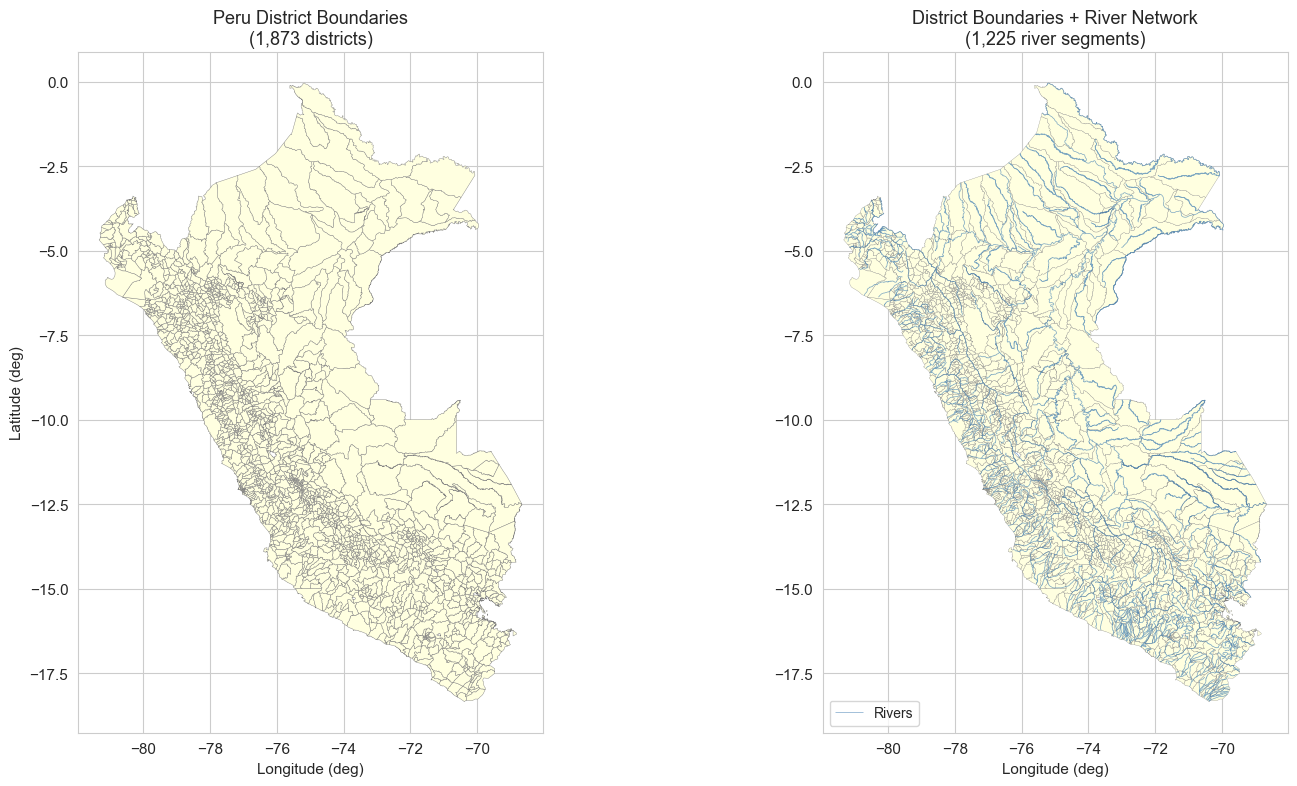

Both vector layers use EPSG:4326, matching the raster CRS.
They can be overlaid with rasters directly — no reprojection needed.


In [11]:
# ── Vector data overview: districts and river network ──
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

gdf_districts.plot(ax=axes[0], color='lightyellow', edgecolor='gray', linewidth=0.3)
axes[0].set_title(f'Peru District Boundaries\n({len(gdf_districts):,} districts)', fontsize=13)
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')

gdf_districts.plot(ax=axes[1], color='lightyellow', edgecolor='gray', linewidth=0.2)
gdf_rivers.plot(ax=axes[1], color='steelblue', linewidth=0.5, alpha=0.7, label='Rivers')
axes[1].set_title(
    f'District Boundaries + River Network\n({len(gdf_rivers):,} river segments)', fontsize=13)
axes[1].set_xlabel('Longitude (deg)')
axes[1].legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

print('Both vector layers use EPSG:4326, matching the raster CRS.')
print('They can be overlaid with rasters directly — no reprojection needed.')

## Section 3: Spatial Subsetting — Three Ways to Crop a Raster

### Why crop?
Our rasters cover a rectangular bounding box extending beyond Peru's borders. Cropping:
- Removes irrelevant ocean and neighboring-country data
- Speeds up computation (smaller arrays = faster processing)
- Focuses visualizations on the area of interest

### Three methods, progressively more specific

| Method | Use Case |
|--------|----------|
| **1. National boundary** — all district polygons | Remove ocean; keep only Peru |
| **2. Department boundary** — filtered polygons | Zoom into one administrative unit |
| **3. Custom bounding box** — rectangle geometry | Extract any custom area of interest |

### Core function: `rasterio.mask.mask(src, shapes, crop=True)`

```python
out_image, out_transform = mask(src, geometries, crop=True, nodata=np.nan)
```

- `src`: Open rasterio dataset
- `geometries`: Iterable of Shapely geometries
- `crop=True`: Shrinks output to the **tight bounding box** of the shapes
- Returns `out_image` (NumPy array) and `out_transform` (new Affine transform)

In [12]:
# ── Method 1: Crop precipitation to Peru national boundary ──

# Ensure CRS matches (both are EPSG:4326 — this is a safety check)
if gdf_districts.crs != prec_crs:
    gdf_districts = gdf_districts.to_crs(prec_crs)

with rasterio.open(prec_path) as src:
    prec_peru, prec_peru_transform = mask(
        src,
        gdf_districts.geometry,   # all 1,873 district polygons
        crop=True,
        nodata=np.nan
    )
    prec_peru_meta = src.meta.copy()

prec_peru_meta.update({
    'height'   : prec_peru.shape[1],
    'width'    : prec_peru.shape[2],
    'transform': prec_peru_transform,
    'nodata'   : np.nan,
    'dtype'    : 'float64'
})

print(f'Original size : {prec_bands.shape[1]} rows x {prec_bands.shape[2]} cols')
print(f'Cropped (Peru): {prec_peru.shape[1]} rows x {prec_peru.shape[2]} cols')
print(f'Bands preserved: {prec_peru.shape[0]}')

with rasterio.open('recorte.tif', 'w', **prec_peru_meta) as dest:
    dest.write(prec_peru)
print()
print('Saved: recorte.tif')

Original size : 198 rows x 133 cols
Cropped (Peru): 185 rows x 126 cols
Bands preserved: 5

Saved: recorte.tif


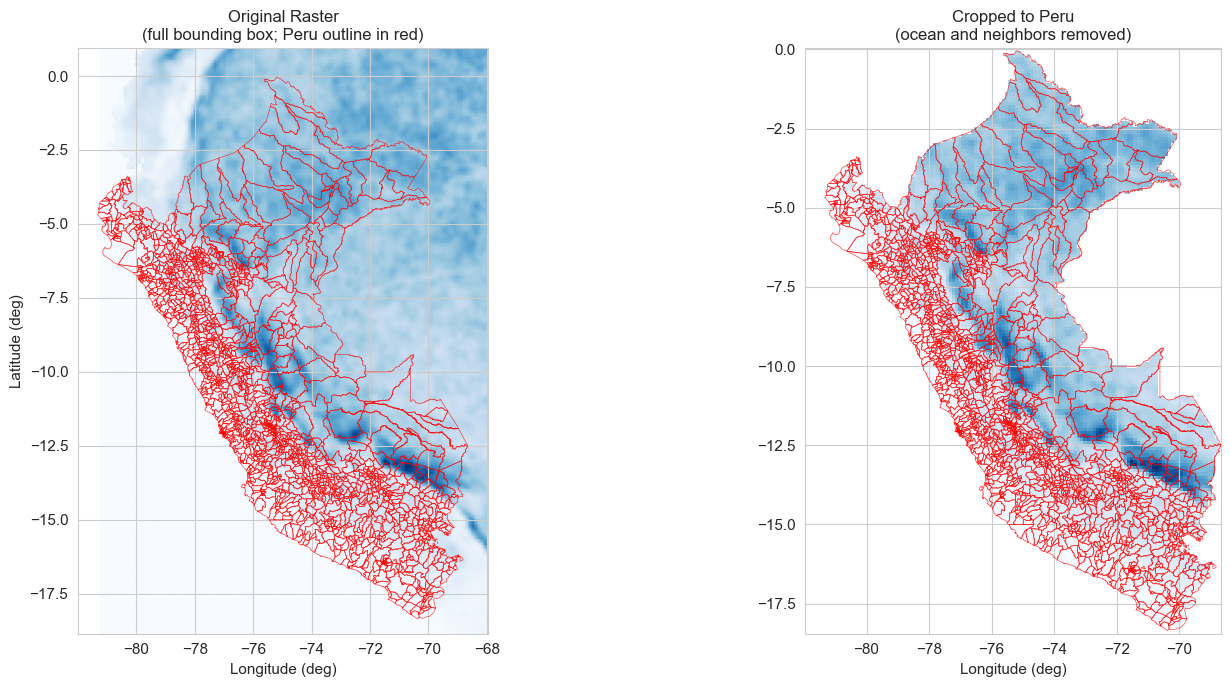

In [13]:
# ── Visualize: original vs. Peru crop ──

# Compute geographic extent from the cropped transform
h_p, w_p = prec_peru.shape[1], prec_peru.shape[2]
l_p, b_p, r_p, t_p = array_bounds(h_p, w_p, prec_peru_transform)
peru_extent = (l_p, r_p, b_p, t_p)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

orig = prec_bands[0].astype(float)
orig[orig < 0] = np.nan
axes[0].imshow(orig, cmap='Blues', extent=prec_extent, origin='upper')
gdf_districts.boundary.plot(ax=axes[0], color='red', linewidth=0.5, alpha=0.7)
axes[0].set_title('Original Raster\n(full bounding box; Peru outline in red)', fontsize=12)
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')

axes[1].imshow(prec_peru[0], cmap='Blues', extent=peru_extent, origin='upper')
gdf_districts.boundary.plot(ax=axes[1], color='red', linewidth=0.5, alpha=0.7)
axes[1].set_title('Cropped to Peru\n(ocean and neighbors removed)', fontsize=12)
axes[1].set_xlabel('Longitude (deg)')

plt.tight_layout()
plt.show()

Loreto has 53 districts.
Loreto bounding box: (-77.82595798699998, -8.715191383665228, -69.94903935499991, -0.03860596799995619)
Loreto crop size: 88 rows x 80 cols
Saved: recorte_loreto.tif


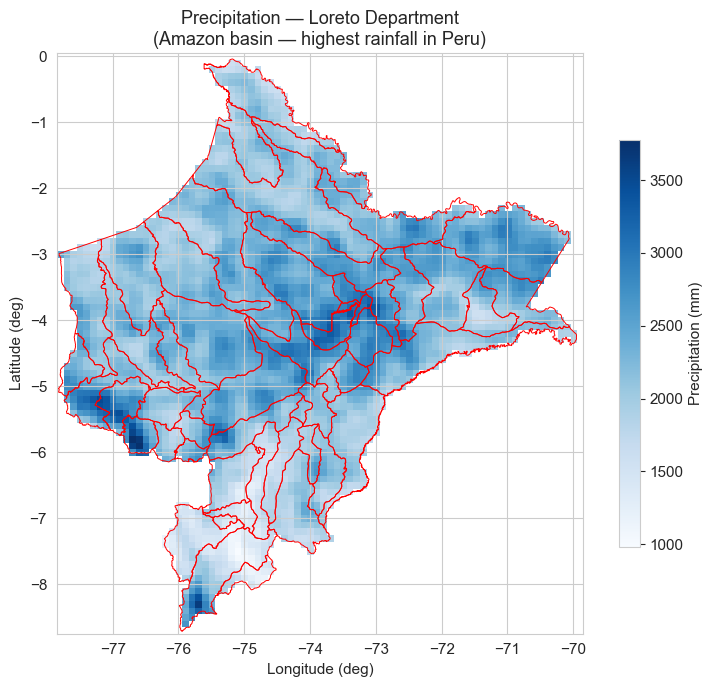

In [14]:
# ── Method 2: Crop to Loreto department ──
loreto_districts = gdf_districts[gdf_districts['DEPARTAMEN'] == 'LORETO']
print(f'Loreto has {len(loreto_districts)} districts.')

# union_all() merges all Loreto polygons into one shape
# (modern replacement for deprecated unary_union)
loreto_union = loreto_districts.union_all()
print(f'Loreto bounding box: {loreto_union.bounds}')

with rasterio.open(prec_path) as src:
    prec_loreto, prec_loreto_transform = mask(
        src,
        [loreto_union],    # single polygon in a list
        crop=True,
        nodata=np.nan
    )
    prec_loreto_meta = src.meta.copy()

prec_loreto_meta.update({
    'height'   : prec_loreto.shape[1],
    'width'    : prec_loreto.shape[2],
    'transform': prec_loreto_transform,
    'nodata'   : np.nan,
    'dtype'    : 'float64'
})
print(f'Loreto crop size: {prec_loreto.shape[1]} rows x {prec_loreto.shape[2]} cols')

with rasterio.open('recorte_loreto.tif', 'w', **prec_loreto_meta) as dest:
    dest.write(prec_loreto)
print('Saved: recorte_loreto.tif')

# Visualize
h_l, w_l = prec_loreto.shape[1], prec_loreto.shape[2]
l_l, b_l, r_l, t_l = array_bounds(h_l, w_l, prec_loreto_transform)
loreto_extent = (l_l, r_l, b_l, t_l)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(prec_loreto[0], cmap='Blues', extent=loreto_extent, origin='upper')
loreto_districts.boundary.plot(ax=ax, color='red', linewidth=0.7)
plt.colorbar(im, ax=ax, shrink=0.7, label='Precipitation (mm)')
ax.set_title('Precipitation — Loreto Department\n(Amazon basin — highest rainfall in Peru)',
             fontsize=13)
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
plt.tight_layout()
plt.show()

In [15]:
# ── Method 3: Crop to a custom bounding box (Central Andes) ──
# Focus area: central Andes corridor  lon -78 to -72, lat -16 to -9
bbox_geom = box(-78.0, -16.0, -72.0, -9.0)    # shapely box(minx, miny, maxx, maxy)

print('Custom Bounding Box — Central Andes Corridor:')
print('  Longitude: -78.0 to -72.0 deg')
print('  Latitude : -16.0 to  -9.0 deg')

with rasterio.open(prec_path) as src:
    prec_andes, prec_andes_transform = mask(
        src, [bbox_geom], crop=True, nodata=np.nan
    )

h_a, w_a = prec_andes.shape[1], prec_andes.shape[2]
l_a, b_a, r_a, t_a = array_bounds(h_a, w_a, prec_andes_transform)
andes_extent = (l_a, r_a, b_a, t_a)

print(f'Andes crop size: {h_a} rows x {w_a} cols')

Custom Bounding Box — Central Andes Corridor:
  Longitude: -78.0 to -72.0 deg
  Latitude : -16.0 to  -9.0 deg
Andes crop size: 71 rows x 61 cols


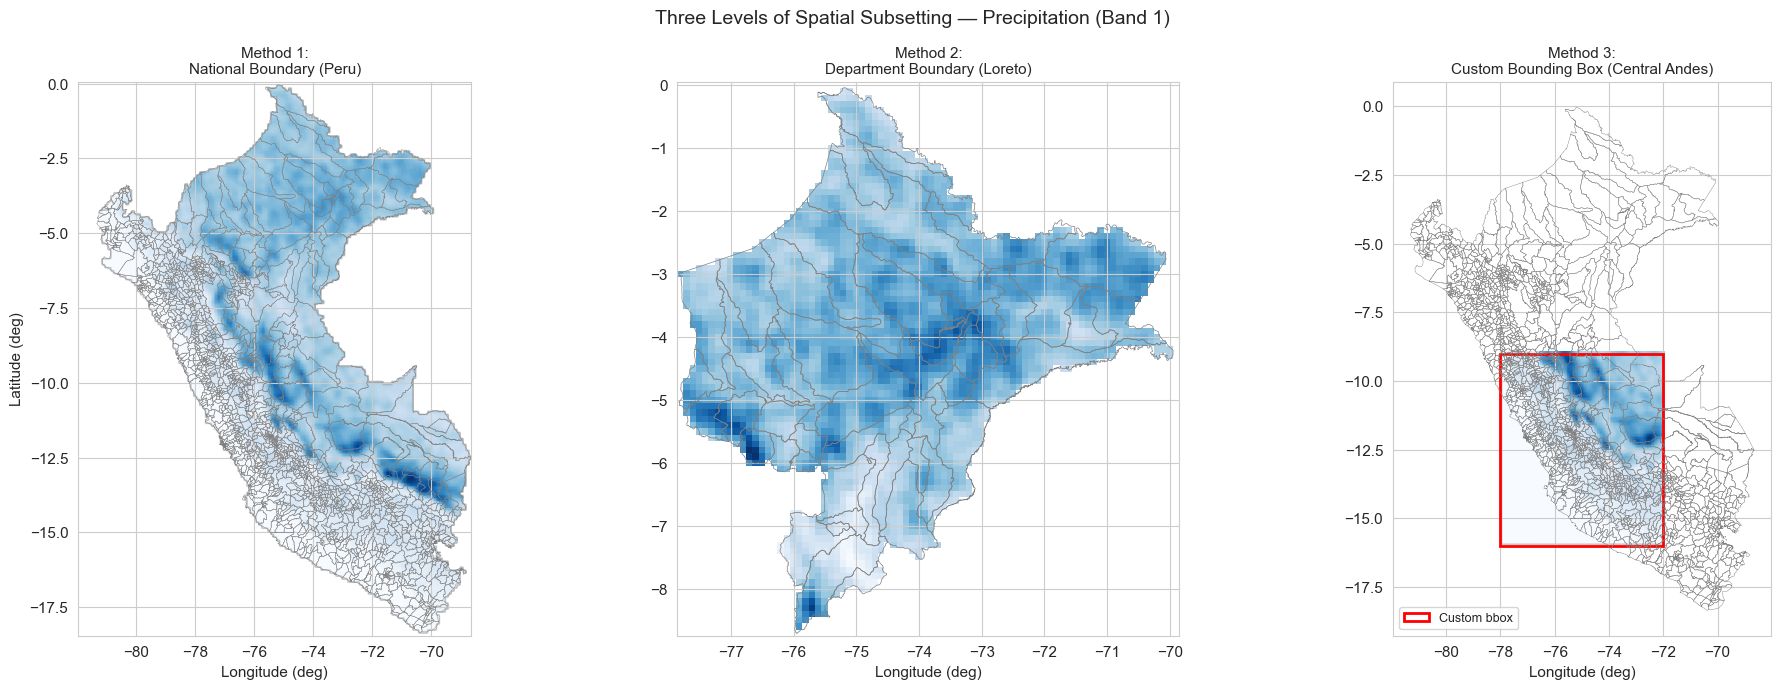

From left to right: national scope -> regional scope -> custom area of interest.


In [16]:
# ── Side-by-side comparison: all three crop methods ──
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Three Levels of Spatial Subsetting — Precipitation (Band 1)', fontsize=14)

# Method 1: Peru
axes[0].imshow(prec_peru[0], cmap='Blues', extent=peru_extent, origin='upper')
gdf_districts.boundary.plot(ax=axes[0], color='gray', linewidth=0.3)
axes[0].set_title('Method 1:\nNational Boundary (Peru)', fontsize=11)
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')

# Method 2: Loreto
axes[1].imshow(prec_loreto[0], cmap='Blues', extent=loreto_extent, origin='upper')
loreto_districts.boundary.plot(ax=axes[1], color='gray', linewidth=0.5)
axes[1].set_title('Method 2:\nDepartment Boundary (Loreto)', fontsize=11)
axes[1].set_xlabel('Longitude (deg)')

# Method 3: Bounding box
axes[2].imshow(prec_andes[0], cmap='Blues', extent=andes_extent, origin='upper')
gdf_districts.boundary.plot(ax=axes[2], color='gray', linewidth=0.3)
rect = Rectangle((-78, -16), 6, 7, linewidth=2, edgecolor='red', facecolor='none',
                 label='Custom bbox')
axes[2].add_patch(rect)
axes[2].set_title('Method 3:\nCustom Bounding Box (Central Andes)', fontsize=11)
axes[2].set_xlabel('Longitude (deg)')
axes[2].legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

print('From left to right: national scope -> regional scope -> custom area of interest.')

## Section 4: Zonal Statistics — Aggregating Rasters by Polygon

### The question:
**"What is the average precipitation in each district?"**

This is a **zonal statistics** problem:

```
District polygon  →  collects pixels: [1200mm, 1350mm, 980mm, 1100mm]
                  →  mean = 1158mm, min = 980mm, max = 1350mm
```

### Why zonal statistics?
Agricultural policy is set at the district level. The Ministry needs *one number per district*, not a grid of pixel values. Zonal statistics bridges the gap between raster science and policy-ready tables.

### `zonal_stats()` key parameters

| Parameter | Purpose |
|-----------|---------|
| `vectors` | GeoDataFrame or shapefile path (the zones) |
| `raster` | Path to the raster file on disk |
| `stats` | Statistics to compute: `['mean', 'min', 'max', 'std', 'count']` |
| `band` | Which raster band to use (1-indexed) |
| `nodata` | Pixel value to exclude from calculations |

In [17]:
# ── Zonal statistics: precipitation — all 5 bands ──
print('Computing zonal statistics for precipitation (5 bands)...')
print('This may take 30-90 seconds for 1,873 districts.')
print()

prec_stats_list = []
for band_num in range(1, 6):
    stats = zonal_stats(
        gdf_districts,
        prec_path,
        stats=['mean', 'min', 'max', 'std'],
        band=band_num,
        nodata=-9999
    )
    df_band = pd.DataFrame(stats)
    df_band.columns = [f'prec_{col}_b{band_num}' for col in df_band.columns]
    prec_stats_list.append(df_band)
    print(f'  Band {band_num} done.')

# Combine all bands and attach district identifiers
prec_df = pd.concat(prec_stats_list, axis=1)
prec_df.insert(0, 'DISTRITO',   gdf_districts['DISTRITO'].values)
prec_df.insert(1, 'DEPARTAMEN', gdf_districts['DEPARTAMEN'].values)

# Average mean across all 5 time periods
mean_cols = [f'prec_mean_b{i}' for i in range(1, 6)]
prec_df['prec_mean_all'] = prec_df[mean_cols].mean(axis=1)

print()
print(f'Result: {prec_df.shape[0]:,} districts x {prec_df.shape[1]} columns')
display(prec_df[['DISTRITO', 'DEPARTAMEN', 'prec_mean_b1', 'prec_mean_b5', 'prec_mean_all']].head(8))

Computing zonal statistics for precipitation (5 bands)...
This may take 30-90 seconds for 1,873 districts.

  Band 1 done.
  Band 2 done.
  Band 3 done.
  Band 4 done.
  Band 5 done.

Result: 1,873 districts x 23 columns


,DISTRITO,DEPARTAMEN,prec_mean_b1,prec_mean_b5,prec_mean_all
0,CODO DEL POZUZO,HUANUCO,3189.469952,3293.733474,3206.759375
1,TOURNAVISTA,HUANUCO,1741.302002,1923.189453,1789.191479
2,ALEXANDER VON HUMBOLDT,UCAYALI,1638.798340,2028.414062,1772.605688
3,IRAZOLA,UCAYALI,2646.981250,3067.729688,2866.884271
4,NESHUYA,UCAYALI,1943.351440,2283.150391,2037.506616
5,PADRE ABAD,UCAYALI,3396.698828,3716.495703,3596.079688
6,CURIMANA,UCAYALI,2249.673410,2649.848493,2287.912779
7,PUERTO INCA,HUANUCO,2348.258203,2494.163281,2364.537031


In [18]:
# ── Zonal statistics: temperature rasters — both Tmax and Tmin ──
print('Computing zonal statistics for temperature rasters...')

tmax_means_list, tmin_means_list = [], []

for band_num in range(1, 6):
    tmax_s = zonal_stats(gdf_districts, tmax_path,
                         stats=['mean'], band=band_num, nodata=-9999)
    tmin_s = zonal_stats(gdf_districts, tmin_path,
                         stats=['mean'], band=band_num, nodata=-9999)
    tmax_means_list.append([s['mean'] for s in tmax_s])
    tmin_means_list.append([s['mean'] for s in tmin_s])
    print(f'  Temperature band {band_num} done.')

# Average across all 5 time periods
tmax_arr = np.array(tmax_means_list, dtype=float)   # shape (5, 1873)
tmin_arr = np.array(tmin_means_list, dtype=float)

# Attach results to the GeoDataFrame
gdf_districts = gdf_districts.copy()
gdf_districts['tmax_mean'] = np.nanmean(tmax_arr, axis=0)
gdf_districts['tmin_mean'] = np.nanmean(tmin_arr, axis=0)
gdf_districts['prec_mean'] = prec_df['prec_mean_all'].values

print()
print('Zonal statistics complete.')
print(f'  Mean Tmax across Peru: {gdf_districts["tmax_mean"].mean():.1f} C')
print(f'  Mean Tmin across Peru: {gdf_districts["tmin_mean"].mean():.1f} C')
print(f'  Mean Prec across Peru: {gdf_districts["prec_mean"].mean():.0f} mm')
print()
display(gdf_districts[['DISTRITO', 'DEPARTAMEN', 'prec_mean', 'tmax_mean', 'tmin_mean']].head(5))

Computing zonal statistics for temperature rasters...
  Temperature band 1 done.
  Temperature band 2 done.
  Temperature band 3 done.
  Temperature band 4 done.
  Temperature band 5 done.

Zonal statistics complete.
  Mean Tmax across Peru: 22.1 C
  Mean Tmin across Peru: 9.5 C
  Mean Prec across Peru: 815 mm



C:\Users\Jean Pool\AppData\Local\Temp\ipykernel_19048\1796390672.py:21: RuntimeWarning: Mean of empty slice
  gdf_districts['tmax_mean'] = np.nanmean(tmax_arr, axis=0)
C:\Users\Jean Pool\AppData\Local\Temp\ipykernel_19048\1796390672.py:22: RuntimeWarning: Mean of empty slice
  gdf_districts['tmin_mean'] = np.nanmean(tmin_arr, axis=0)


,DISTRITO,DEPARTAMEN,prec_mean,tmax_mean,tmin_mean
0,CODO DEL POZUZO,HUANUCO,3206.759375,28.662086,18.761000
1,TOURNAVISTA,HUANUCO,1789.191479,31.383749,22.048223
2,ALEXANDER VON HUMBOLDT,UCAYALI,1772.605688,31.917710,21.862907
3,IRAZOLA,UCAYALI,2866.884271,31.511820,22.097315
4,NESHUYA,UCAYALI,2037.506616,32.076945,21.937903


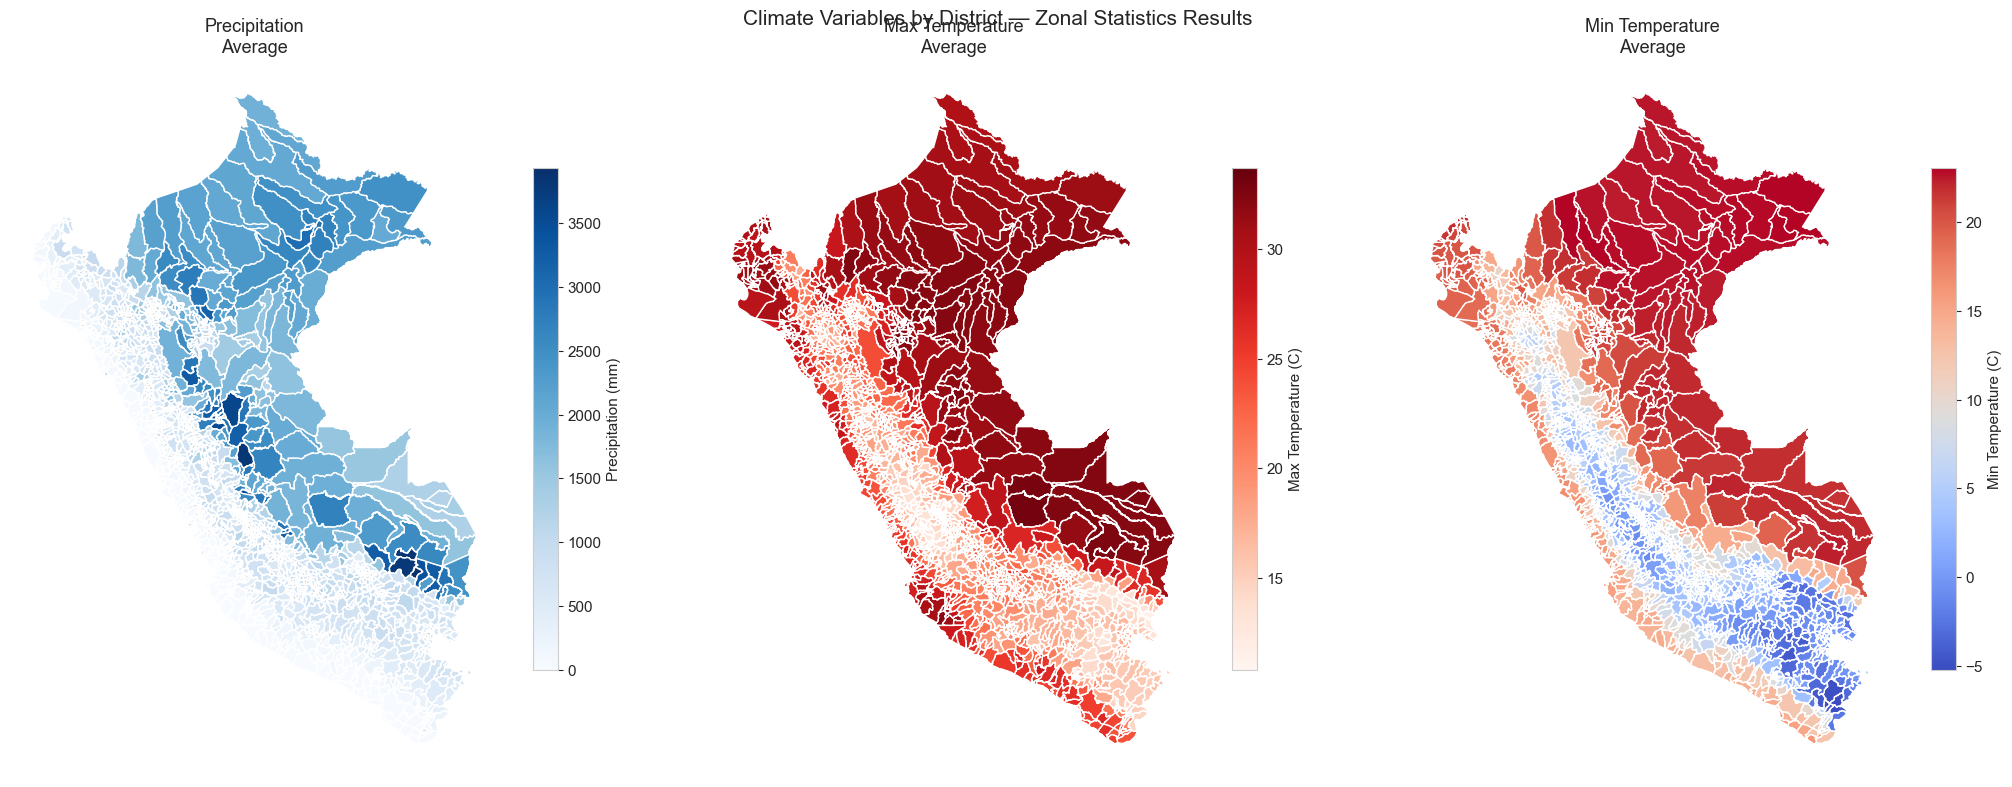

Spatial patterns:
  Precipitation : Wet Amazon (east/north)  ->  Dry Pacific coast (west)
  Max Temp      : Hot lowlands  ->  Cooler highlands
  Min Temp      : Cold Andean peaks  ->  Warm Amazon basin


In [19]:
# ── Choropleth maps: all three climate variables ──
fig, axes = plt.subplots(1, 3, figsize=(21, 8))
fig.suptitle('Climate Variables by District — Zonal Statistics Results', fontsize=15)

configs = [
    ('prec_mean',  'Blues',    'Precipitation (mm)',   'Precipitation\nAverage'),
    ('tmax_mean',  'Reds',     'Max Temperature (C)',  'Max Temperature\nAverage'),
    ('tmin_mean',  'coolwarm', 'Min Temperature (C)',  'Min Temperature\nAverage'),
]

for ax, (col, cmap, label, title) in zip(axes, configs):
    gdf_districts.plot(
        column=col, ax=ax, cmap=cmap, legend=True,
        missing_kwds={'color': 'lightgray', 'label': 'No data'},
        legend_kwds={'label': label, 'shrink': 0.7}
    )
    gdf_districts.boundary.plot(ax=ax, color='white', linewidth=0.1, alpha=0.3)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('Spatial patterns:')
print('  Precipitation : Wet Amazon (east/north)  ->  Dry Pacific coast (west)')
print('  Max Temp      : Hot lowlands  ->  Cooler highlands')
print('  Min Temp      : Cold Andean peaks  ->  Warm Amazon basin')

## Section 5: Exploratory Statistical Analysis

Before building a climate risk index we need to understand the **distributions** of our three climate variables:

- Are they normally distributed or skewed?
- Are there outliers (districts with extreme values)?
- How do conditions vary across departments?

These questions inform the threshold choices in Section 6.

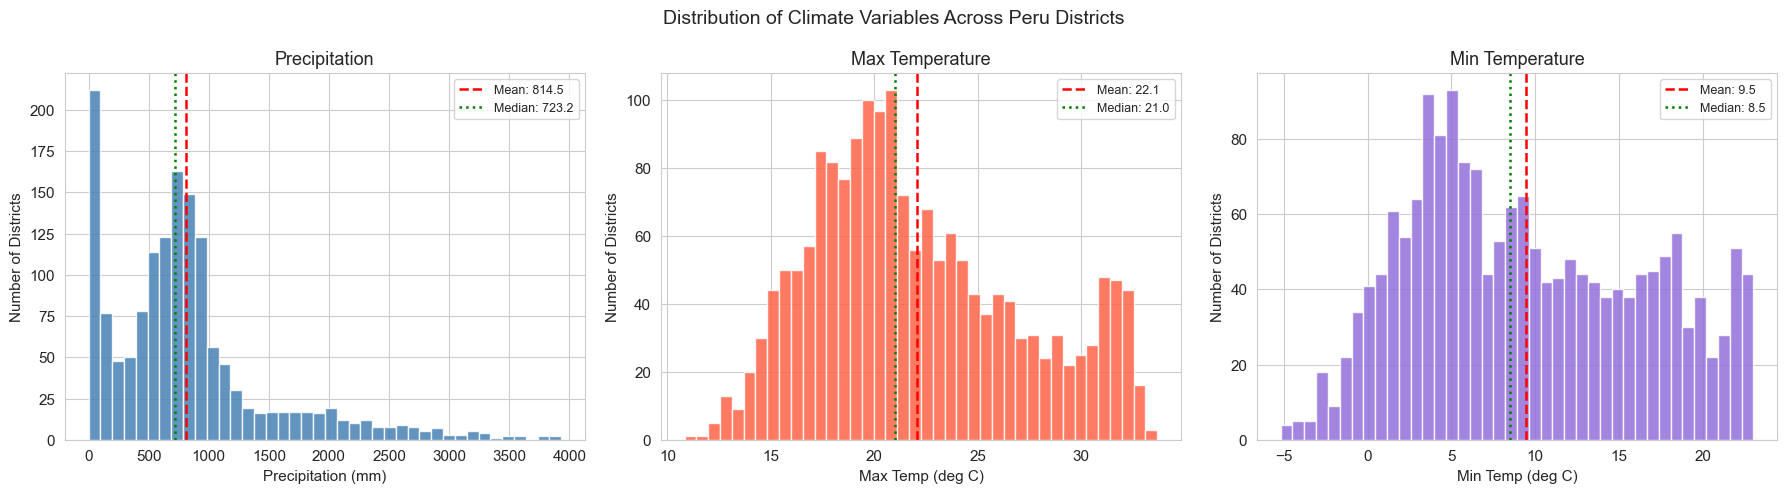

Descriptive Statistics:
       Precipitation (mm)  Max Temp (C)  Min Temp (C)
count             1510.00       1789.00       1789.00
mean               814.50         22.05          9.45
std                686.89          5.05          6.88
min                  0.00         10.83         -5.19
25%                376.99         18.26          3.94
50%                723.24         21.00          8.48
75%                979.08         25.49         15.13
max               3932.27         33.68         23.01


In [20]:
# ── Histograms + descriptive statistics ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Climate Variables Across Peru Districts', fontsize=14)

var_configs = [
    ('prec_mean',  'steelblue',    'Precipitation (mm)',  'Precipitation'),
    ('tmax_mean',  'tomato',       'Max Temp (deg C)',    'Max Temperature'),
    ('tmin_mean',  'mediumpurple', 'Min Temp (deg C)',    'Min Temperature'),
]

for ax, (col, color, xlabel, title) in zip(axes, var_configs):
    data = gdf_districts[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.8,
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle=':',  linewidth=1.8,
               label=f'Median: {data.median():.1f}')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of Districts')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

summary = gdf_districts[['prec_mean', 'tmax_mean', 'tmin_mean']].describe().round(2)
summary.columns = ['Precipitation (mm)', 'Max Temp (C)', 'Min Temp (C)']
print('Descriptive Statistics:')
print(summary.to_string())

C:\Users\Jean Pool\AppData\Local\Temp\ipykernel_19048\2178262252.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


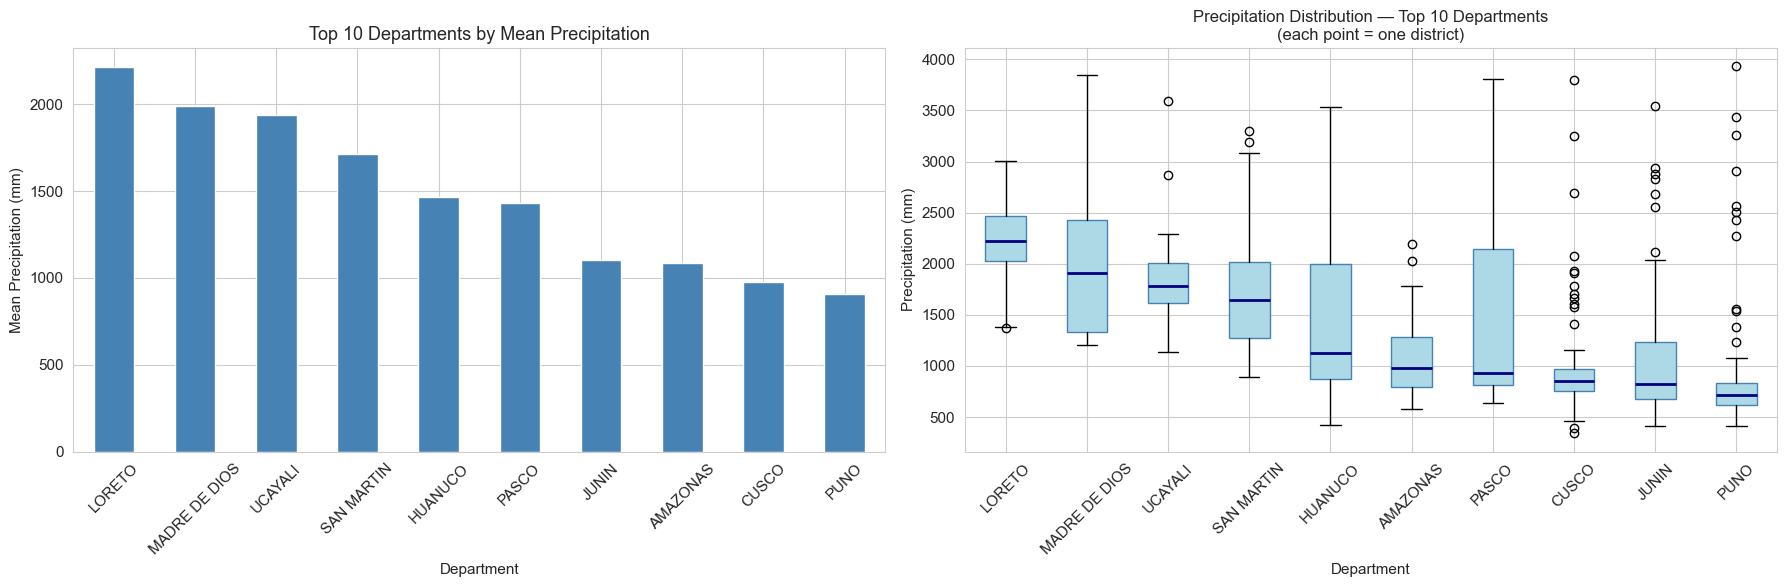

In [21]:
# ── Department-level analysis: bar chart + boxplot ──
dept_stats = (
    gdf_districts.groupby('DEPARTAMEN')[['prec_mean', 'tmax_mean', 'tmin_mean']]
    .mean().round(2)
    .sort_values('prec_mean', ascending=False)
)

top10_depts = dept_stats.head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
dept_stats.head(10)['prec_mean'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Departments by Mean Precipitation', fontsize=13)
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Mean Precipitation (mm)')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot
subset = gdf_districts[gdf_districts['DEPARTAMEN'].isin(top10_depts)].copy()
dept_order = (subset.groupby('DEPARTAMEN')['prec_mean']
              .median().sort_values(ascending=False).index.tolist())
data_to_plot = [
    subset[subset['DEPARTAMEN'] == d]['prec_mean'].dropna().values
    for d in dept_order
]
axes[1].boxplot(
    data_to_plot, labels=dept_order, patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='steelblue'),
    medianprops=dict(color='navy', linewidth=2)
)
axes[1].set_title('Precipitation Distribution — Top 10 Departments\n(each point = one district)',
                  fontsize=12)
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

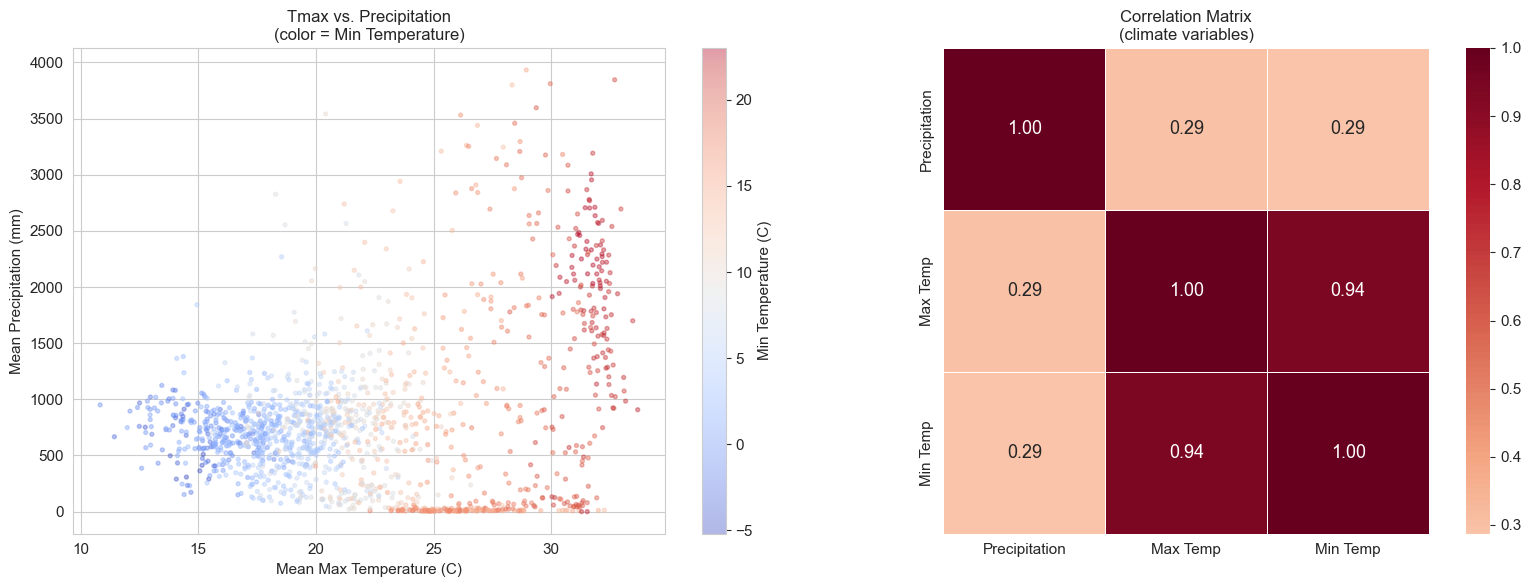

Precipitation vs Max Temp: r = 0.290
Precipitation vs Min Temp: r = 0.287


In [22]:
# ── Correlation analysis: scatter plot + heatmap ──
valid = gdf_districts[['prec_mean', 'tmax_mean', 'tmin_mean']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(
    valid['tmax_mean'], valid['prec_mean'],
    c=valid['tmin_mean'], cmap='coolwarm', alpha=0.4, s=8
)
plt.colorbar(sc, ax=axes[0], label='Min Temperature (C)')
axes[0].set_xlabel('Mean Max Temperature (C)')
axes[0].set_ylabel('Mean Precipitation (mm)')
axes[0].set_title('Tmax vs. Precipitation\n(color = Min Temperature)', fontsize=12)

corr = valid.rename(columns={
    'prec_mean': 'Precipitation', 'tmax_mean': 'Max Temp', 'tmin_mean': 'Min Temp'
}).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], square=True, linewidths=0.5,
            annot_kws={'size': 13})
axes[1].set_title('Correlation Matrix\n(climate variables)', fontsize=12)

plt.tight_layout()
plt.show()

r_p_tmax = valid['prec_mean'].corr(valid['tmax_mean'])
r_p_tmin = valid['prec_mean'].corr(valid['tmin_mean'])
print(f'Precipitation vs Max Temp: r = {r_p_tmax:.3f}')
print(f'Precipitation vs Min Temp: r = {r_p_tmin:.3f}')

## Section 6: Combining Rasters — Building a Climate Risk Index

### The central question for the Ministry of Agriculture:
> *"Which districts are at highest risk for agricultural failure due to climate stress?"*

We define two risk components:

### Drought Risk
High temperatures + low rainfall = **water stress** for crops:
- `drought_hot` = 1 if mean max temperature > **75th percentile** (hottest 25% of districts)
- `drought_dry` = 1 if mean precipitation < **25th percentile** (driest 25% of districts)

### Frost Risk
Very low minimum temperatures damage or kill frost-sensitive crops:
- `frost_risk` = 1 if mean min temperature < **10th percentile** (coldest 10% of districts)

### Combined Score (0–3)

| Score | Meaning |
|-------|---------|
| 0 | No significant risk |
| 1 | Low risk (one condition triggered) |
| 2 | High risk (two conditions triggered) |
| 3 | Extreme risk (all three conditions triggered) |

### Why percentile thresholds?
Absolute thresholds (e.g., "Tmax > 30°C") are arbitrary. Percentile thresholds adapt to the actual data distribution, making them robust for within-country comparative analysis.

In [23]:
# ── Compute percentile-based thresholds ──
prec_q25 = gdf_districts['prec_mean'].quantile(0.25)
tmax_q75 = gdf_districts['tmax_mean'].quantile(0.75)
tmin_q10 = gdf_districts['tmin_mean'].quantile(0.10)

print('=== Climate Risk Thresholds ===')
print(f'  Drought-dry  (Prec below P25) : below {prec_q25:.0f} mm')
print(f'  Drought-hot  (Tmax above P75) : above {tmax_q75:.1f} C')
print(f'  Frost-risk   (Tmin below P10) : below {tmin_q10:.1f} C')
print()
print(f'  Districts below Prec P25 : {(gdf_districts["prec_mean"] < prec_q25).sum():,}')
print(f'  Districts above Tmax P75 : {(gdf_districts["tmax_mean"] > tmax_q75).sum():,}')
print(f'  Districts below Tmin P10 : {(gdf_districts["tmin_mean"] < tmin_q10).sum():,}')

=== Climate Risk Thresholds ===
  Drought-dry  (Prec below P25) : below 377 mm
  Drought-hot  (Tmax above P75) : above 25.5 C
  Frost-risk   (Tmin below P10) : below 1.1 C

  Districts below Prec P25 : 378
  Districts above Tmax P75 : 447
  Districts below Tmin P10 : 179


In [24]:
# ── Assign risk scores to each district ──
gdf_risk = gdf_districts.copy()

gdf_risk['drought_hot'] = (gdf_risk['tmax_mean'] > tmax_q75).astype(int)
gdf_risk['drought_dry'] = (gdf_risk['prec_mean']  < prec_q25).astype(int)
gdf_risk['frost_risk']  = (gdf_risk['tmin_mean']  < tmin_q10).astype(int)

gdf_risk['risk_score'] = (
    gdf_risk['drought_hot'] +
    gdf_risk['drought_dry'] +
    gdf_risk['frost_risk']
)

risk_labels = {
    0: 'No significant risk',
    1: 'Low risk',
    2: 'High risk',
    3: 'Extreme risk'
}
gdf_risk['risk_category'] = gdf_risk['risk_score'].map(risk_labels)

print('=== Risk Score Distribution ===')
score_counts = gdf_risk['risk_score'].value_counts().sort_index()
for score, count in score_counts.items():
    pct = count / len(gdf_risk) * 100
    label = risk_labels.get(score, '?')
    print(f'  Score {score} ({label:<25s}): {count:4d} districts ({pct:.1f}%)')

print()
high_risk_n = (gdf_risk['risk_score'] >= 2).sum()
print(f'Districts with HIGH or EXTREME risk (score >= 2): {high_risk_n:,}')

=== Risk Score Distribution ===
  Score 0 (No significant risk      ): 1033 districts (55.2%)
  Score 1 (Low risk                 ):  676 districts (36.1%)
  Score 2 (High risk                ):  164 districts (8.8%)

Districts with HIGH or EXTREME risk (score >= 2): 164


In [25]:
# ── High-risk districts by department ──
high_risk = gdf_risk[gdf_risk['risk_score'] >= 2].copy()

dept_risk = (
    high_risk.groupby('DEPARTAMEN')
    .agg(
        high_risk_districts=('DISTRITO', 'count'),
        avg_risk_score=('risk_score', 'mean'),
        avg_tmax=('tmax_mean', 'mean'),
        avg_prec=('prec_mean', 'mean'),
        avg_tmin=('tmin_mean', 'mean')
    )
    .round(2)
    .sort_values('high_risk_districts', ascending=False)
)

print('Departments ranked by number of high-risk districts (score >= 2):')
print()
print(dept_risk.to_string())

Departments ranked by number of high-risk districts (score >= 2):

             high_risk_districts  avg_risk_score  avg_tmax  avg_prec  avg_tmin
DEPARTAMEN                                                                    
ICA                           30             2.0     28.57     20.59     14.54
AREQUIPA                      25             2.0     25.14     47.85     11.84
PIURA                         24             2.0     30.79     98.62     19.92
LAMBAYEQUE                    22             2.0     28.64    123.79     18.36
LA LIBERTAD                   19             2.0     26.94     45.03     17.75
ANCASH                        13             2.0     26.77     39.51     16.65
LIMA                          11             2.0     26.02      6.28     16.14
TACNA                         10             2.0     17.24    206.14      0.52
TUMBES                         4             2.0     30.75     64.45     22.08
CAJAMARCA                      3             2.0     27.29    24

## Section 7: Final Maps — Agricultural Climate Risk Atlas

We now produce the final outputs for the Ministry:

1. **Climate Risk Choropleth**: District-level risk score map (0–3 scale, 4 colors)
2. **Risk + River Network**: Risk map overlaid with the river network
3. **Department Dashboard**: Summary bar charts for policy communication

### Why rivers matter for risk assessment:
Districts with high **drought risk** that are **far from rivers** have the least adaptive capacity — no irrigation from surface water. Districts near rivers may offset rainfall deficits with alternative water sources. This overlay gives the Ministry a more nuanced picture for prioritizing interventions.

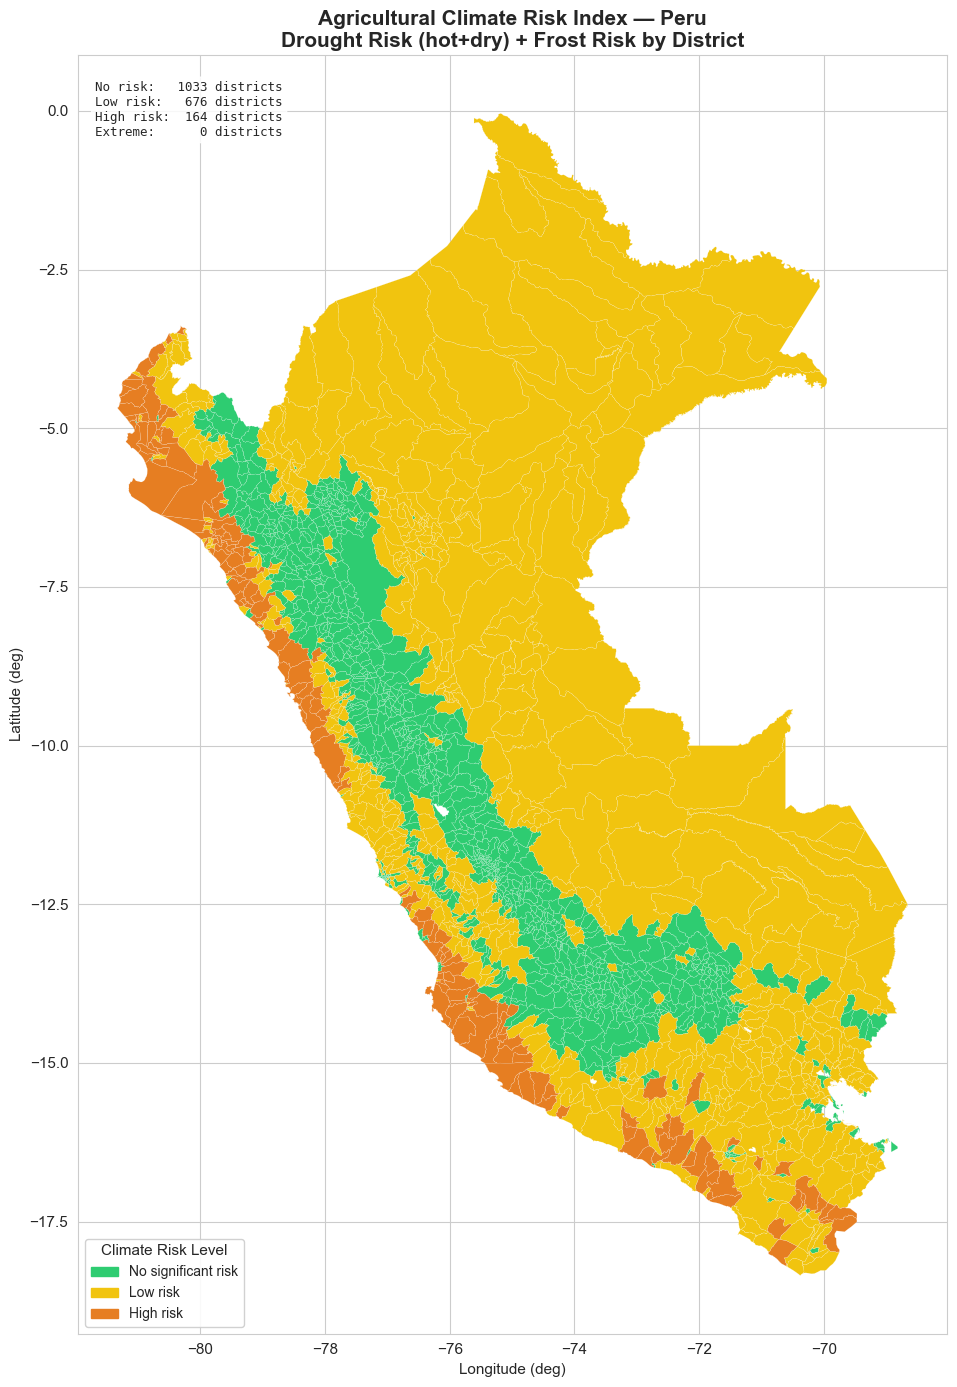

In [26]:
# ── Main climate risk choropleth ──
risk_colors = {
    'No significant risk': '#2ecc71',
    'Low risk'           : '#f1c40f',
    'High risk'          : '#e67e22',
    'Extreme risk'       : '#c0392b'
}

gdf_risk['risk_plot'] = gdf_risk['risk_category'].fillna('No data')
risk_colors['No data'] = '#d0d0d0'

fig, ax = plt.subplots(figsize=(11, 14))

for category, color in risk_colors.items():
    subset = gdf_risk[gdf_risk['risk_plot'] == category]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.1)

patches = [
    mpatches.Patch(color=c, label=lbl)
    for lbl, c in risk_colors.items()
    if lbl in gdf_risk['risk_plot'].unique()
]
ax.legend(handles=patches, loc='lower left', title='Climate Risk Level',
          fontsize=10, title_fontsize=11, framealpha=0.9)

ax.set_title(
    'Agricultural Climate Risk Index — Peru\nDrought Risk (hot+dry) + Frost Risk by District',
    fontsize=15, fontweight='bold'
)
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')

score_text = (
    f'No risk:   {(gdf_risk["risk_score"]==0).sum():>4d} districts\n'
    f'Low risk:  {(gdf_risk["risk_score"]==1).sum():>4d} districts\n'
    f'High risk: {(gdf_risk["risk_score"]==2).sum():>4d} districts\n'
    f'Extreme:   {(gdf_risk["risk_score"]==3).sum():>4d} districts'
)
ax.text(0.02, 0.98, score_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.show()

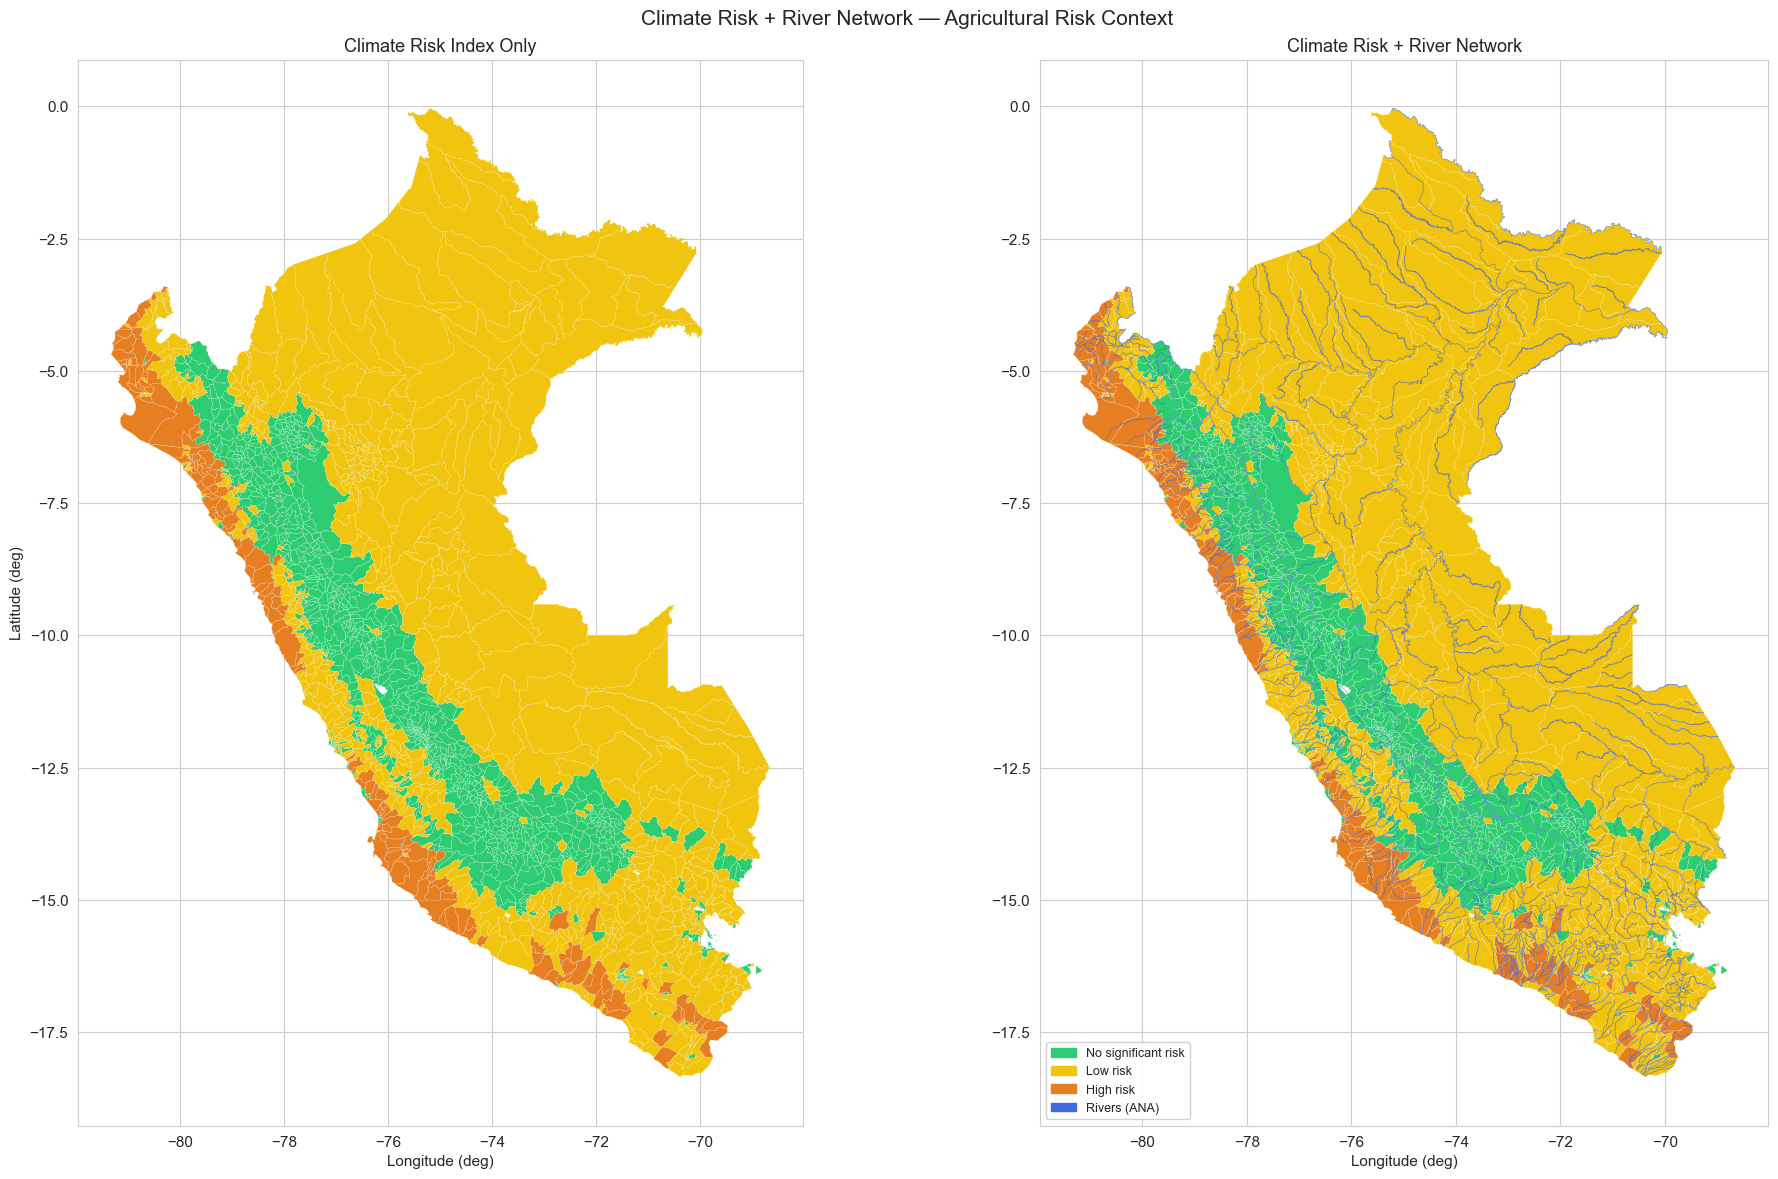

Observation: High-risk coastal districts (west) are largely away from major rivers.
River network concentrates in the Amazon basin (east), where drought risk is minimal.


In [27]:
# ── Risk map + river network overlay ──
fig, axes = plt.subplots(1, 2, figsize=(20, 12))
fig.suptitle('Climate Risk + River Network — Agricultural Risk Context', fontsize=15)

for ax in axes:
    for category, color in risk_colors.items():
        subset = gdf_risk[gdf_risk['risk_plot'] == category]
        if not subset.empty:
            subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.1)

axes[0].set_title('Climate Risk Index Only', fontsize=13)
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')

gdf_rivers.plot(ax=axes[1], color='royalblue', linewidth=0.5, alpha=0.7,
                label='Rivers (ANA)')
axes[1].set_title('Climate Risk + River Network', fontsize=13)
axes[1].set_xlabel('Longitude (deg)')

all_patches = [
    mpatches.Patch(color=c, label=lbl)
    for lbl, c in risk_colors.items()
    if lbl in gdf_risk['risk_plot'].unique()
]
all_patches.append(mpatches.Patch(color='royalblue', label='Rivers (ANA)'))
axes[1].legend(handles=all_patches, loc='lower left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

print('Observation: High-risk coastal districts (west) are largely away from major rivers.')
print('River network concentrates in the Amazon basin (east), where drought risk is minimal.')

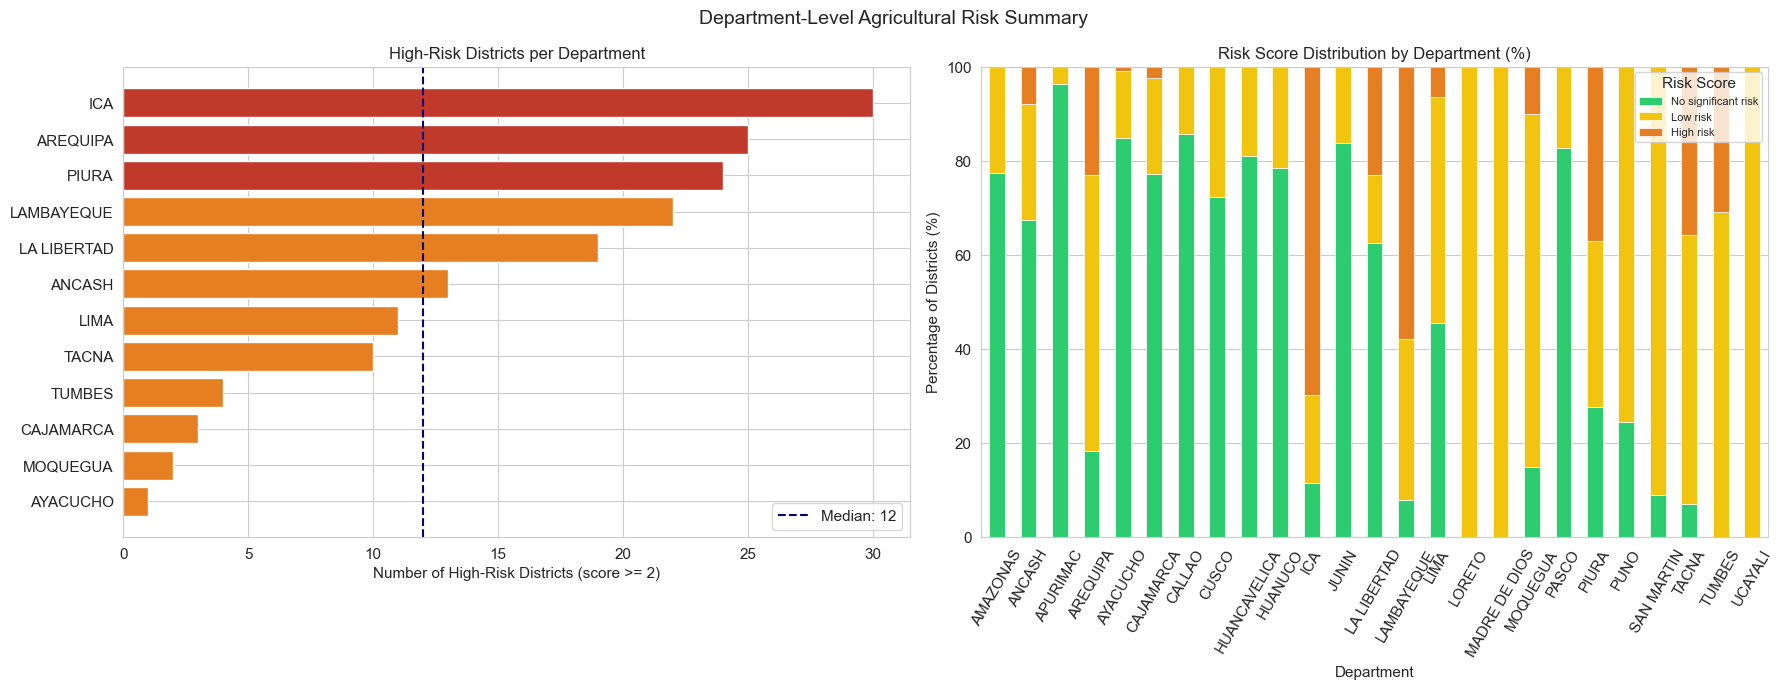

In [28]:
# ── Department summary dashboard ──
dept_risk_count = (
    gdf_risk[gdf_risk['risk_score'] >= 2]
    .groupby('DEPARTAMEN')['DISTRITO'].count()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Department-Level Agricultural Risk Summary', fontsize=14)

bar_colors = [
    '#c0392b' if v >= dept_risk_count.quantile(0.75) else '#e67e22'
    for v in dept_risk_count.values
]
axes[0].barh(dept_risk_count.index, dept_risk_count.values,
             color=bar_colors, edgecolor='white')
axes[0].set_xlabel('Number of High-Risk Districts (score >= 2)')
axes[0].set_title('High-Risk Districts per Department', fontsize=12)
median_val = dept_risk_count.median()
axes[0].axvline(median_val, color='navy', linestyle='--',
                label=f'Median: {median_val:.0f}')
axes[0].legend()

risk_by_dept = (
    gdf_risk.groupby(['DEPARTAMEN', 'risk_score']).size().unstack(fill_value=0)
)
risk_by_dept_pct = risk_by_dept.div(risk_by_dept.sum(axis=1), axis=0) * 100
score_colors_map = {0: '#2ecc71', 1: '#f1c40f', 2: '#e67e22', 3: '#c0392b'}
avail_scores = [c for c in [0, 1, 2, 3] if c in risk_by_dept_pct.columns]

risk_by_dept_pct[avail_scores].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[score_colors_map[s] for s in avail_scores],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('Risk Score Distribution by Department (%)', fontsize=12)
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Percentage of Districts (%)')
axes[1].legend(title='Risk Score',
               labels=[risk_labels[s] for s in avail_scores],
               loc='upper right', fontsize=8)
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

## Section 8: Key Findings and Next Steps

### What We Built

| Step | Tool | What We Did |
|------|------|-------------|
| **Read** | `rasterio` | Loaded raster metadata: dimensions, bands, CRS, affine transform |
| **Visualize** | `matplotlib` | Plotted single bands, multi-band series, geographic extents |
| **Crop** | `rasterio.mask` | Applied three types of spatial subsetting |
| **Quantify** | `rasterstats` | Aggregated pixel-level data to district-level summaries |
| **Combine** | `numpy` / `pandas` | Created composite climate risk index from three variables |
| **Communicate** | `geopandas` + `matplotlib` | Produced choropleth maps and charts for policy briefings |

### Key Findings
- **Pacific coast** districts (Ica, Lima, Piura, Tumbes) → high drought risk: hot and very dry
- **Andes highlands** (Puno, Cusco, Arequipa) → frost risk from very low minimum temperatures
- **Loreto** (Amazon basin) → highest precipitation; minimal drought risk
- The **river network** concentrates in the Amazon basin, offering limited irrigation relief to the dry coastal zones

### Limitations and Next Steps
- The 5 time periods are anonymous; linking to calendar months would enable seasonal analysis
- Equal weights for all three risk components; a real model would weight by crop type
- Adding elevation data would refine frost risk estimates in highlands
- Population and cropland maps would prioritize which districts to address first

### Further Resources
- [rasterio documentation](https://rasterio.readthedocs.io/)
- [rasterstats documentation](https://pythonhosted.org/rasterstats/)
- [GeoPandas documentation](https://geopandas.org/en/stable/)

In [ ]:
# ── Export final results for Ministry reporting ──
output_cols = [
    'IDDPTO', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO',
    'prec_mean', 'tmax_mean', 'tmin_mean',
    'drought_hot', 'drought_dry', 'frost_risk',
    'risk_score', 'risk_category'
]

export_df = gdf_risk[output_cols].sort_values(
    ['risk_score', 'DEPARTAMEN'], ascending=[False, True]
)

export_df.to_csv('climate_risk_by_district.csv', index=False, encoding='utf-8-sig')

print('Saved: climate_risk_by_district.csv')
print(f'  Rows    : {len(export_df):,}')
print(f'  Columns : {export_df.columns.tolist()}')

print()
print('--- Top 10 Highest-Risk Districts ---')
top10 = export_df.head(10).copy()
top10['prec_mean'] = top10['prec_mean'].round(0).astype('Int64')
top10['tmax_mean'] = top10['tmax_mean'].round(1)
top10['tmin_mean'] = top10['tmin_mean'].round(1)
print(top10[['DEPARTAMEN', 'DISTRITO', 'prec_mean', 'tmax_mean',
             'tmin_mean', 'risk_score', 'risk_category']].to_string(index=False))